Sampling frequency: 360
Total samples: 650000
Duration (seconds): 1805.5555555555557


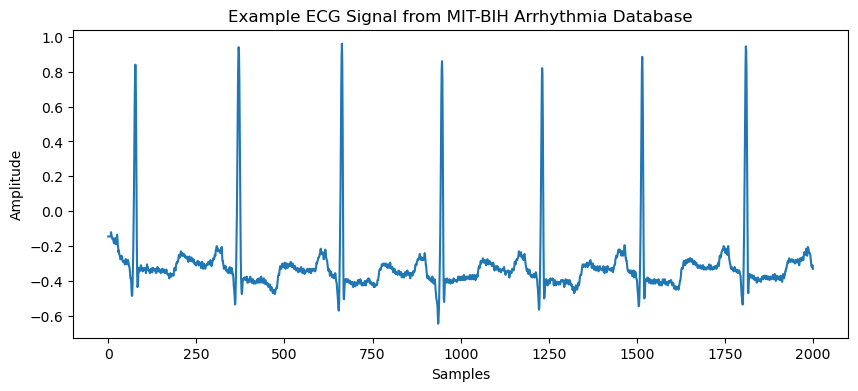

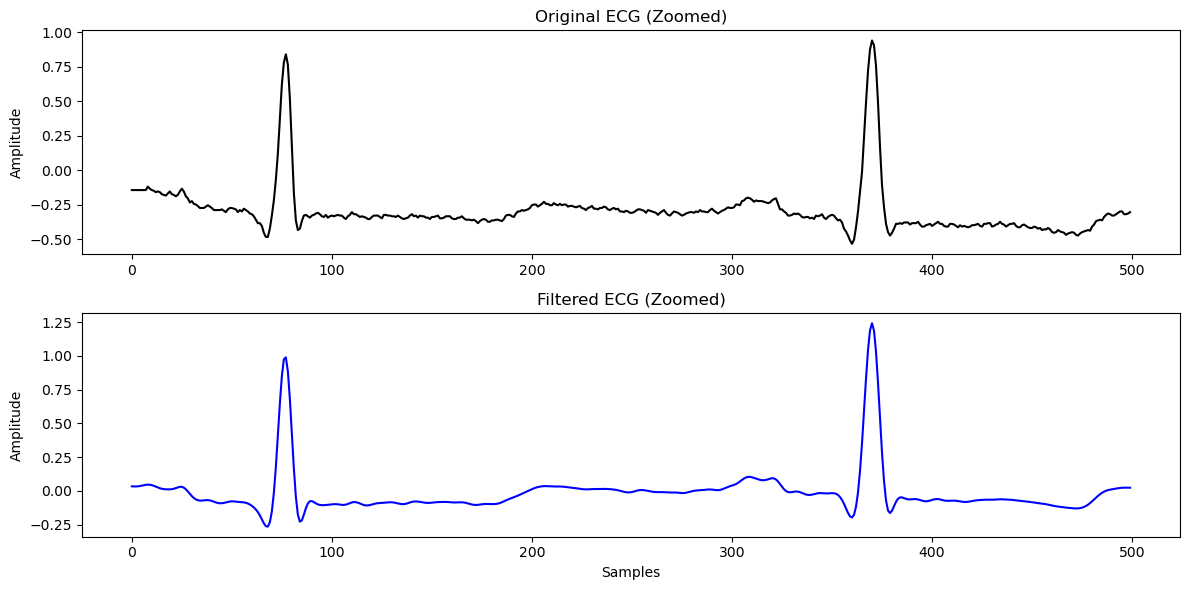

Total heartbeat segments: (2271, 200)


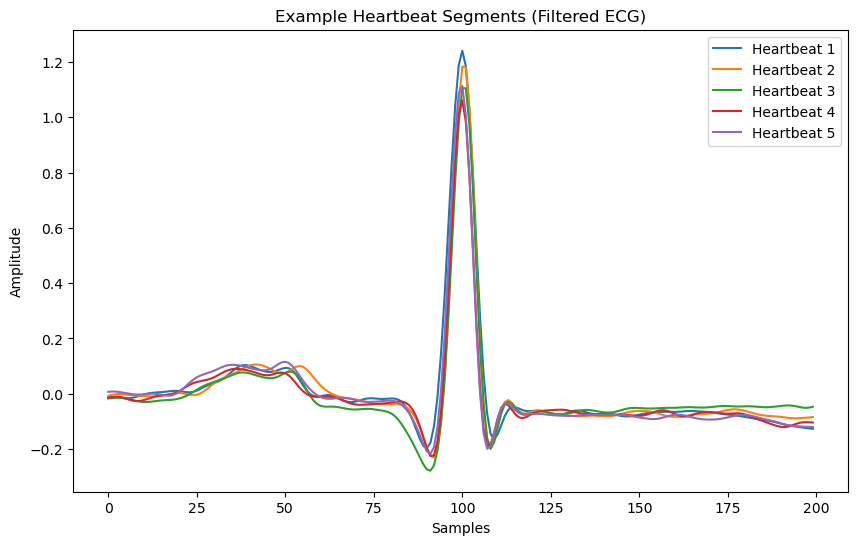

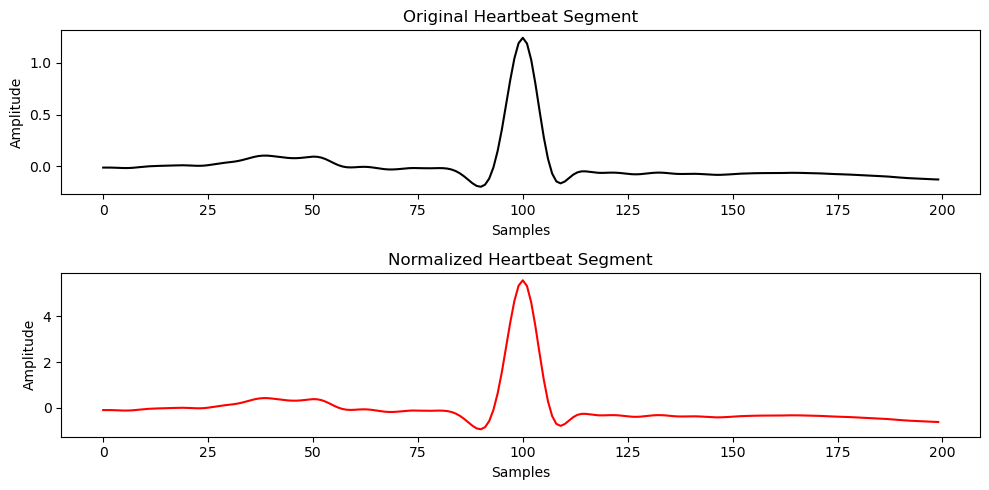

In [1]:
# ===============================
# 1 Import Libraries
# ===============================
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ===============================
# 2 Load MIT-BIH ECG Dataset
# ===============================
DATA_PATH = "/Users/cathy/Desktop/mitdb"

record = wfdb.rdrecord(DATA_PATH + "/100")
annotation = wfdb.rdann(DATA_PATH + "/100", "atr")

signal = record.p_signal[:,0]
fs = record.fs

print("Sampling frequency:", fs)
print("Total samples:", len(signal))
print("Duration (seconds):", len(signal)/fs)

# ===============================
# 3 Plot Example ECG Signal
# ===============================
plt.figure(figsize=(10,4))
plt.plot(signal[0:2000])
plt.title("Example ECG Signal from MIT-BIH Arrhythmia Database")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.savefig("ecg_example.png", dpi=300)
plt.show()


# ===============================
# 4 Bandpass Filter
# ===============================
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=4):

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)

    return filtered

filtered_signal = bandpass_filter(signal, fs)


# ===============================
# 5 Compare Original vs Filtered ECG
# ===============================
start = 0
end = 500

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(signal[start:end], color='black')
plt.title("Original ECG (Zoomed)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(filtered_signal[start:end], color='blue')
plt.title("Filtered ECG (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.savefig("ecg_zoom_comparison.png", dpi=300)
plt.show()


# ===============================
# 6 Heartbeat Segmentation
# ===============================
r_peaks = annotation.sample

segments = []
window = 100  # 左右100 → 共200 samples

for r in r_peaks:

    if r-window >= 0 and r+window < len(filtered_signal):

        segment = filtered_signal[r-window:r+window]
        segments.append(segment)

segments = np.array(segments)

print("Total heartbeat segments:", segments.shape)


# ===============================
# 7 Plot Heartbeat Segments
# ===============================
plt.figure(figsize=(10,6))

for i in range(5):
    plt.plot(segments[i], label=f"Heartbeat {i+1}")

plt.title("Example Heartbeat Segments (Filtered ECG)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

plt.savefig("heartbeat_segments.png", dpi=300)
plt.show()


# ===============================
# 8 Normalization Example
# ===============================
heartbeat = segments[0]

normalized = (heartbeat - np.mean(heartbeat)) / np.std(heartbeat)

plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.plot(heartbeat, color='black')
plt.title("Original Heartbeat Segment")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(normalized, color='red')
plt.title("Normalized Heartbeat Segment")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.savefig("normalization_example.png", dpi=300)
plt.show()